# Korean to English Seq2Seq + Bahdanau Attention Translator

- Source language: Korean
- Target language: English
- Model: Encoder-Decoder GRU + Bahdanau Attention

In [ ]:
import os
import re
import random
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    from konlpy.tag import Mecab
except Exception as exc:
    raise RuntimeError(
        "KoNLPy Mecab을 불러오지 못했습니다."
    ) from exc




f:\code\AIFFEL\AIFFEL_quest_eng\NLP\NLP01\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)




device: cuda


## Step 1. 데이터 경로



In [3]:
data_dir = Path("./datasets_ko_en")
if not (data_dir / "korean-english-park.train.en").exists():
    fallback_data_dir = Path("F:/code/AIFFEL/AIFFEL_quest_eng/NLP/NLP01/datasets_ko_en")
    if fallback_data_dir.exists():
        data_dir = fallback_data_dir

eng_path = data_dir / "korean-english-park.train.en"
kor_path = data_dir / "korean-english-park.train.ko"

assert eng_path.exists(), f"영어 데이터 파일을 찾을 수 없습니다: {eng_path.resolve()}"
assert kor_path.exists(), f"한국어 데이터 파일을 찾을 수 없습니다: {kor_path.resolve()}"


def read_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]


eng_lines = read_lines(eng_path)
kor_lines = read_lines(kor_path)

assert len(eng_lines) == len(kor_lines), "영어/한국어 데이터 줄 수가 다릅니다."
print(f"raw pairs: {len(kor_lines):,}")
print("KOR:", kor_lines[0])
print("ENG:", eng_lines[0])




raw pairs: 94,123
KOR: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
ENG: Much of personal computing is about "can you top this?"


## Step 2. 데이터 정제

`set`을 사용하되, 영어/한국어를 따로 중복 제거하면 병렬쌍이 깨질 수 있습니다.
반드시 `(한국어, 영어)` 튜플 단위로 중복 제거합니다.



In [4]:
seen_pairs = set()
cleaned_corpus = []

for kor, eng in zip(kor_lines, eng_lines):
    pair = (kor.strip(), eng.strip())
    if not pair[0] or not pair[1]:
        continue
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)
    cleaned_corpus.append(pair)

print(f"cleaned pairs: {len(cleaned_corpus):,}")
print(f"removed duplicates/empty pairs: {len(kor_lines) - len(cleaned_corpus):,}")




cleaned pairs: 78,941
removed duplicates/empty pairs: 15,182


In [5]:
def preprocessing(sentence, lang):
    """English/Korean sentence normalization for this parallel corpus."""
    sentence = unicodedata.normalize("NFKC", str(sentence)).strip()

    if lang == "en":
        sentence = sentence.lower()
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r"[^a-z0-9?.!,']+", " ", sentence)
    elif lang == "ko":
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,%]+", " ", sentence)
    else:
        raise ValueError("lang must be 'en' or 'ko'")

    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


print(preprocessing("오바마는 대통령이다.", "ko"))
print(preprocessing("Obama is the president.", "en"))




오바마는 대통령이다 .
obama is the president .


uv pip install mecab-ko 설치후
import mecab_ko as MeCab 로 변경

In [11]:
import mecab_ko as MeCab

class Mecab:
    def __init__(self):
        self.tagger = MeCab.Tagger("-Owakati")

    def morphs(self, text):
        return self.tagger.parse(text).strip().split()

mecab = Mecab()

MAX_LEN = 40
kor_corpus = []
eng_corpus = []

for kor, eng in tqdm(cleaned_corpus, desc="preprocess/tokenize"):
    kor_sentence = preprocessing(kor, "ko")
    eng_sentence = preprocessing(eng, "en")

    kor_tokens = mecab.morphs(kor_sentence)
    eng_tokens = ["<start>"] + eng_sentence.split() + ["<end>"]

    if 0 < len(kor_tokens) <= MAX_LEN and 2 < len(eng_tokens) <= MAX_LEN:
        kor_corpus.append(" ".join(kor_tokens))
        eng_corpus.append(" ".join(eng_tokens))

print(f"length-filtered pairs: {len(kor_corpus):,}")
print("KOR tokens:", kor_corpus[0])
print("ENG tokens:", eng_corpus[0])




preprocess/tokenize:   0%|          | 0/78941 [00:00<?, ?it/s]

preprocess/tokenize: 100%|██████████| 78941/78941 [00:05<00:00, 13592.27it/s]

length-filtered pairs: 61,273
KOR tokens: 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?
ENG tokens: <start> much of personal computing is about can you top this ? <end>


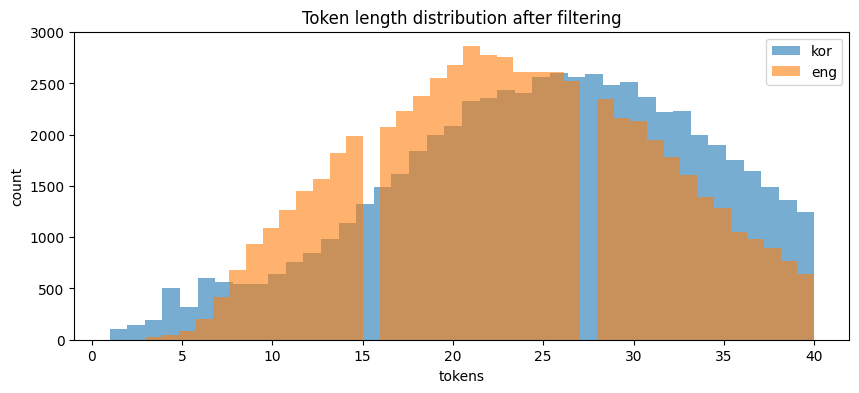

In [12]:
plt.figure(figsize=(10, 4))
plt.hist([len(s.split()) for s in kor_corpus], bins=40, alpha=0.6, label="kor")
plt.hist([len(s.split()) for s in eng_corpus], bins=40, alpha=0.6, label="eng")
plt.legend()
plt.title("Token length distribution after filtering")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()




## Step 3. 데이터 토큰화

TensorFlow/Keras가 설치되어 있으면 `keras.preprocessing.text.Tokenizer`를 사용합니다.
없는 환경에서도 실행되도록 동일한 역할을 하는 작은 fallback tokenizer를 함께 둡니다.



In [13]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    USING_KERAS_TOKENIZER = True
except Exception:
    USING_KERAS_TOKENIZER = False

    class Tokenizer:
        def __init__(self, num_words=None, filters="", lower=False, oov_token="<unk>"):
            self.num_words = num_words
            self.filters = filters
            self.lower = lower
            self.oov_token = oov_token
            self.word_index = {}
            self.index_word = {}

        def fit_on_texts(self, texts):
            counter = Counter()
            first_seen = {}

            for text in texts:
                if self.lower:
                    text = text.lower()
                for token in text.split():
                    counter[token] += 1
                    if token not in first_seen:
                        first_seen[token] = len(first_seen)

            idx = 1
            if self.oov_token is not None:
                self.word_index[self.oov_token] = idx
                self.index_word[idx] = self.oov_token
                idx += 1

            sorted_tokens = sorted(counter.items(), key=lambda x: (-x[1], first_seen[x[0]]))
            for token, _ in sorted_tokens:
                if token == self.oov_token:
                    continue
                self.word_index[token] = idx
                self.index_word[idx] = token
                idx += 1

        def texts_to_sequences(self, texts):
            sequences = []
            oov_id = self.word_index.get(self.oov_token)
            for text in texts:
                if self.lower:
                    text = text.lower()
                seq = []
                for token in text.split():
                    token_id = self.word_index.get(token, oov_id)
                    if token_id is None:
                        continue
                    if self.num_words is not None and token_id >= self.num_words:
                        if oov_id is None:
                            continue
                        token_id = oov_id
                    seq.append(token_id)
                sequences.append(seq)
            return sequences


    def pad_sequences(sequences, maxlen, padding="post", truncating="post"):
        padded = np.zeros((len(sequences), maxlen), dtype=np.int64)
        for i, seq in enumerate(sequences):
            if truncating == "post":
                seq = seq[:maxlen]
            else:
                seq = seq[-maxlen:]

            if padding == "post":
                padded[i, : len(seq)] = seq
            else:
                padded[i, -len(seq) :] = seq
        return padded


print("using keras tokenizer:", USING_KERAS_TOKENIZER)




using keras tokenizer: True


In [14]:
def tokenize(corpus, vocab_size, max_len):
    tokenizer = Tokenizer(
        num_words=vocab_size,
        filters="",
        lower=False,
        oov_token="<unk>",
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequences(tensor, maxlen=max_len, padding="post", truncating="post")
    return tensor, tokenizer


KOR_VOCAB_SIZE = 15000
ENG_VOCAB_SIZE = 15000

kor_tensor, kor_tokenizer = tokenize(kor_corpus, KOR_VOCAB_SIZE, MAX_LEN)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, ENG_VOCAB_SIZE, MAX_LEN)

print("kor_tensor:", kor_tensor.shape)
print("eng_tensor:", eng_tensor.shape)
print("kor vocab:", min(KOR_VOCAB_SIZE, len(kor_tokenizer.word_index) + 1))
print("eng vocab:", min(ENG_VOCAB_SIZE, len(eng_tokenizer.word_index) + 1))




kor_tensor: (61273, 40)
eng_tensor: (61273, 40)
kor vocab: 15000
eng vocab: 15000


In [15]:
PAD_ID = 0
BOS_ID = eng_tokenizer.word_index["<start>"]
EOS_ID = eng_tokenizer.word_index["<end>"]

print("PAD_ID:", PAD_ID)
print("BOS_ID:", BOS_ID)
print("EOS_ID:", EOS_ID)




PAD_ID: 0
BOS_ID: 4
EOS_ID: 5


In [16]:
class TranslationDataset(Dataset):
    def __init__(self, src_tensor, trg_tensor):
        self.src_tensor = torch.tensor(src_tensor, dtype=torch.long)
        self.trg_input = torch.tensor(trg_tensor[:, :-1], dtype=torch.long)
        self.trg_label = torch.tensor(trg_tensor[:, 1:], dtype=torch.long)

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        return self.src_tensor[idx], self.trg_input[idx], self.trg_label[idx]


BATCH_SIZE = 64
dataset = TranslationDataset(kor_tensor, eng_tensor)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

src_batch, trg_input_batch, trg_label_batch = next(iter(train_loader))
print(src_batch.shape, trg_input_batch.shape, trg_label_batch.shape)




torch.Size([64, 40]) torch.Size([64, 39]) torch.Size([64, 39])


## Step 4. 모델 설계

원래 노트북의 GRU 기반 Seq2Seq + Bahdanau Attention 구조를 유지하되,
인코더를 bidirectional GRU로 구성하고 decoder RNN 입력에도 context vector를 넣어
attention 정보를 더 직접적으로 활용하게 했습니다.



In [17]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.W_dec = nn.Linear(dec_hidden_dim, dec_hidden_dim)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        # hidden: (1, batch, dec_hidden_dim)
        # encoder_outputs: (batch, src_len, enc_hidden_dim * 2)
        hidden = hidden[-1].unsqueeze(1)

        energy = torch.tanh(self.W_enc(encoder_outputs) + self.W_dec(hidden))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(mask == 0, -1e10)

        return torch.softmax(scores, dim=1)


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            enc_hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = torch.tanh(self.fc(hidden)).unsqueeze(0)

        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, attention, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim + enc_hidden_dim * 2,
            dec_hidden_dim,
            batch_first=True,
        )
        self.fc_out = nn.Linear(emb_dim + enc_hidden_dim * 2 + dec_hidden_dim, output_dim)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        # input_token: (batch,)
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        attention_weights = self.attention(hidden, encoder_outputs, mask)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        prediction = self.fc_out(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1),
                    embedded.squeeze(1),
                ),
                dim=1,
            )
        )

        return prediction, hidden, attention_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, pad_id, bos_id, eos_id, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id
        self.device = device

    def create_mask(self, src):
        return src != self.pad_id

    def forward(self, src, trg_input=None, max_len=40, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        src_len = src.shape[1]
        output_dim = self.decoder.output_dim

        encoder_outputs, hidden = self.encoder(src)
        mask = self.create_mask(src)

        if trg_input is not None:
            steps = trg_input.shape[1]
            input_token = trg_input[:, 0]
        else:
            steps = max_len
            input_token = torch.full(
                (batch_size,),
                self.bos_id,
                dtype=torch.long,
                device=self.device,
            )

        outputs = torch.zeros(batch_size, steps, output_dim, device=self.device)
        attentions = torch.zeros(batch_size, steps, src_len, device=self.device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

        for t in range(steps):
            output, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask,
            )

            outputs[:, t] = output
            attentions[:, t] = attention_weights

            top1 = output.argmax(1)

            if trg_input is not None and t + 1 < steps:
                use_teacher = random.random() < teacher_forcing_ratio
                input_token = trg_input[:, t + 1] if use_teacher else top1
            else:
                input_token = top1
                finished |= top1 == self.eos_id
                if trg_input is None and finished.all():
                    break

        return outputs, attentions




In [18]:
def effective_vocab_size(tokenizer, requested_size):
    return min(requested_size, len(tokenizer.word_index) + 1)


INPUT_DIM = effective_vocab_size(kor_tokenizer, KOR_VOCAB_SIZE)
OUTPUT_DIM = effective_vocab_size(eng_tokenizer, ENG_VOCAB_SIZE)
EMB_DIM = 256
ENC_HID_DIM = 256
DEC_HID_DIM = 512
DROPOUT = 0.3

attention = BahdanauAttention(ENC_HID_DIM, DEC_HID_DIM)
encoder = Encoder(INPUT_DIM, EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attention, DROPOUT)

model = Seq2SeqAttention(
    encoder,
    decoder,
    pad_id=PAD_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    device=device,
).to(device)

print(model)




Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15000, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 256, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=512, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=512, out_features=512, bias=True)
      (W_dec): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(15000, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1280, out_features=15000, bias=True)
  )
)


## Step 5. 훈련하기

과제 지시대로 검증 데이터 분리는 하지 않습니다. `eval_step()`도 만들지 않고,
각 epoch마다 과제 예문 번역 결과를 확인합니다.



In [19]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)


def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)

        optimizer.zero_grad()

        outputs, _ = model(
            src,
            trg_input,
            teacher_forcing_ratio=0.5,
        )

        output_dim = outputs.shape[-1]
        loss = criterion(
            outputs.reshape(-1, output_dim),
            trg_label.reshape(-1),
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return epoch_loss / len(data_loader)




In [28]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

font_candidates = [
    Path("./fonts/NanumBarunGothic.ttf"),
    Path("F:/code/AIFFEL/AIFFEL_quest_eng/NLP/NLP01/fonts/NanumBarunGothic.ttf"),
    Path("C:/Windows/Fonts/malgun.ttf"),  # Windows 기본 한글 폰트
]

fontpath = next((p for p in font_candidates if p.exists()), None)

if fontpath is None:
    raise FileNotFoundError("사용할 한글 폰트를 찾지 못했습니다.")

fm.fontManager.addfont(str(fontpath))
fontprop = fm.FontProperties(fname=str(fontpath))

plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"설정된 폰트: {fontprop.get_name()}")


설정된 폰트: NanumBarunGothic


In [29]:
def sentence_to_tensor(sentence, tokenizer, max_len=MAX_LEN):
    sentence = preprocessing(sentence, "ko")
    tokens = mecab.morphs(sentence)
    text = " ".join(tokens)
    sequence = tokenizer.texts_to_sequences([text])[0]
    sequence = sequence[:max_len]
    sequence = sequence + [PAD_ID] * (max_len - len(sequence))
    tensor = torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)
    return tensor, tokens


def decode_prediction(token_ids, tokenizer):
    words = []
    for token_id in token_ids:
        token_id = int(token_id)
        if token_id == PAD_ID:
            continue
        word = tokenizer.index_word.get(token_id, "<unk>")
        words.append(word)
        if word == "<end>":
            break
    return words


def evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=MAX_LEN):
    model.eval()
    src_tensor, src_tokens = sentence_to_tensor(sentence, kor_tokenizer, max_len=max_len)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, trg_input=None, max_len=max_len)

    pred_ids = outputs.argmax(dim=-1).squeeze(0).detach().cpu().numpy()
    pred_tokens = decode_prediction(pred_ids, eng_tokenizer)
    attention = attentions.squeeze(0).detach().cpu().numpy()

    return pred_tokens, src_tokens, attention


def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=MAX_LEN, show_attention=False):
    pred_tokens, src_tokens, attention = evaluate(
        sentence,
        model,
        kor_tokenizer,
        eng_tokenizer,
        max_len=max_len,
    )
    translation = " ".join(pred_tokens)

    print(f"KOR: {sentence}")
    print(f"ENG: {translation}")

    if show_attention:
        plot_attention(attention, src_tokens, pred_tokens)

    return translation


def plot_attention(attention, src_tokens, pred_tokens):
    if len(pred_tokens) == 0:
        print("예측 토큰이 없어 attention map을 그릴 수 없습니다.")
        return

    attention = attention[: len(pred_tokens), : len(src_tokens)]

    fig_width = max(6, len(src_tokens) * 0.45)
    fig_height = max(4, len(pred_tokens) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.matshow(attention, cmap="viridis")
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(pred_tokens)))

    ax.set_xticklabels(src_tokens, rotation=90, fontproperties=fontprop)
    ax.set_yticklabels(pred_tokens, fontproperties=fontprop)

    plt.tight_layout()
    plt.show()




In [21]:
EXAMPLE_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]


def run_examples(model):
    for sentence in EXAMPLE_SENTENCES:
        translate(sentence, model, kor_tokenizer, eng_tokenizer, show_attention=False)
    print()




In [22]:
EPOCHS = 15
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    history.append(train_loss)

    print(f"\nEpoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f}")
    run_examples(model)




Epoch 1: 100%|██████████| 958/958 [01:36<00:00,  9.93it/s, loss=5.6134]



Epoch 1/15 | train loss: 6.0099
KOR: 오바마는 대통령이다.
ENG: obama obama is president obama . <end>
KOR: 시민들은 도시 속에 산다.
ENG: the are the to the city of the . . <end>
KOR: 커피는 필요 없다.
ENG: no no . <end>
KOR: 일곱 명의 사망자가 발생했다.
ENG: the least one of people were killed dead . <end>



Epoch 2: 100%|██████████| 958/958 [01:35<00:00, 10.03it/s, loss=5.3611]



Epoch 2/15 | train loss: 5.2265
KOR: 오바마는 대통령이다.
ENG: obama obama president president president president president . <end>
KOR: 시민들은 도시 속에 산다.
ENG: the are the cities cities cities cities . <end>
KOR: 커피는 필요 없다.
ENG: no need to coffee . <end>
KOR: 일곱 명의 사망자가 발생했다.
ENG: the death toll were injured . <end>



Epoch 3: 100%|██████████| 958/958 [01:38<00:00,  9.72it/s, loss=4.7808]


...


Epoch 13/15 | train loss: 3.5733
KOR: 오바마는 대통령이다.
ENG: obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama
KOR: 시민들은 도시 속에 산다.
ENG: citizens citizens are the city's cities cities . <end>
KOR: 커피는 필요 없다.
ENG: there coffee no need coffee coffee . <end>
KOR: 일곱 명의 사망자가 발생했다.
ENG: seven people were killed . <end>



Epoch 14: 100%|██████████| 958/958 [01:34<00:00, 10.17it/s, loss=3.6697]



Epoch 14/15 | train loss: 3.5572
KOR: 오바마는 대통령이다.
ENG: obama obama president president obama . <end>
KOR: 시민들은 도시 속에 산다.
ENG: citizens citizens cities cities cities cities . <end>
KOR: 커피는 필요 없다.
ENG: no coffee coffee coffee coffee coffee coffee coffee . <end>
KOR: 일곱 명의 사망자가 발생했다.
ENG: seven people were killed . <end>



Epoch 15: 100%|██████████| 958/958 [01:34<00:00, 10.18it/s, loss=4.4072]


Epoch 15/15 | train loss: 3.4954
KOR: 오바마는 대통령이다.
ENG: obama is obama obama . <end>
KOR: 시민들은 도시 속에 산다.
ENG: citizens citizens , cities cities cities cities . <end>
KOR: 커피는 필요 없다.
ENG: there is no coffee coffee . <end>
KOR: 일곱 명의 사망자가 발생했다.
ENG: seven deaths were killed . <end>



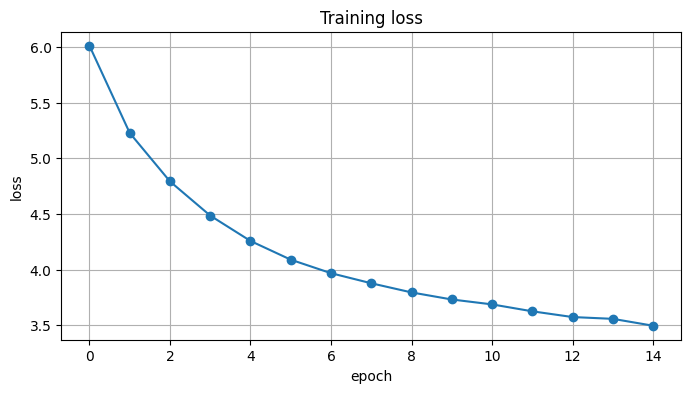

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(history, marker="o")
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.show()




In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "./fonts/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


## 최종 예문 번역 및 Attention Map



KOR: 오바마는 대통령이다.
ENG: obama is obama obama . <end>


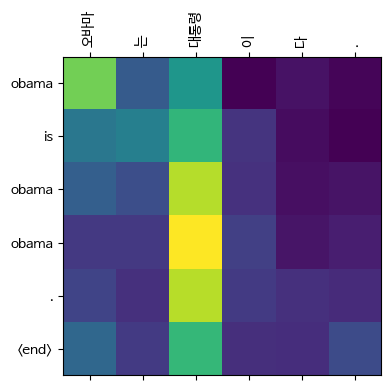

KOR: 시민들은 도시 속에 산다.
ENG: citizens citizens , cities cities cities cities . <end>


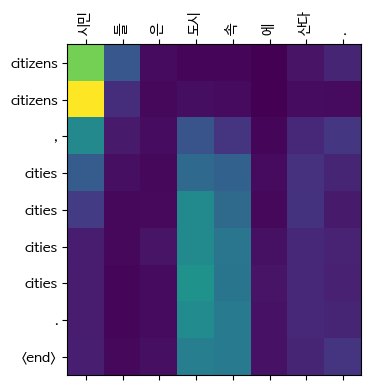

KOR: 커피는 필요 없다.
ENG: there is no coffee coffee . <end>


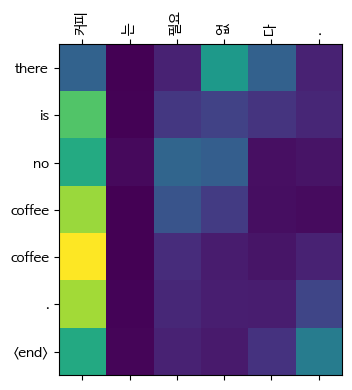

KOR: 일곱 명의 사망자가 발생했다.
ENG: seven deaths were killed . <end>


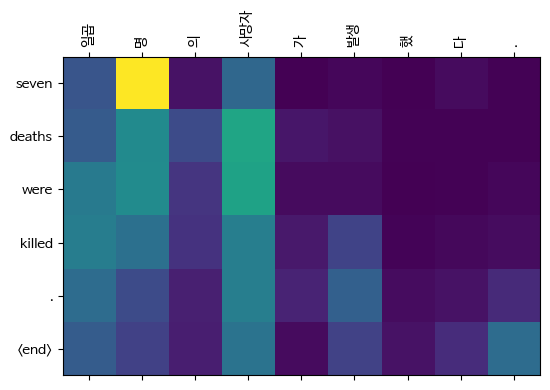

In [30]:
for sentence in EXAMPLE_SENTENCES:
    translate(sentence, model, kor_tokenizer, eng_tokenizer, show_attention=True)


## 선택: 모델 저장



In [27]:
checkpoint_path = "ko_en_seq2seq_attention.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "kor_word_index": kor_tokenizer.word_index,
        "kor_index_word": kor_tokenizer.index_word,
        "eng_word_index": eng_tokenizer.word_index,
        "eng_index_word": eng_tokenizer.index_word,
        "config": {
            "max_len": MAX_LEN,
            "kor_vocab_size": KOR_VOCAB_SIZE,
            "eng_vocab_size": ENG_VOCAB_SIZE,
            "emb_dim": EMB_DIM,
            "enc_hid_dim": ENC_HID_DIM,
            "dec_hid_dim": DEC_HID_DIM,
            "dropout": DROPOUT,
            "pad_id": PAD_ID,
            "bos_id": BOS_ID,
            "eos_id": EOS_ID,
        },
    },
    checkpoint_path,
)

print(f"saved: {checkpoint_path}")


saved: ko_en_seq2seq_attention.pt


## 회고록
https://github.com/ohmanbo/AIFFEL_quest_eng/blob/main/NLP/NLP01/s2s_ko_en_translator.ipynb

처음 파일 은 위 링크 였었고, 영어 번역결과가 너무 길어지고 같은값이 반복되는 문제가있어서 코드 수정 하다가 셀순서가 너무 복잡해져서 AI한테 물어봐도 더이상 손대기 힘든 상황까지 와버려서 새로 만들었어요.

